In [ ]:
from tensorflow.keras.datasets import mnist
# from keras.datasets import mnist

In [ ]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 4988611729904456348
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14426112000
locality {
  bus_id: 1
  links {
  }
}
incarnation: 17647264097452224395
physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
xla_global_id: 416903419
]


In [ ]:
local_devices = device_lib.list_local_devices()

for d in local_devices:
    if d.device_type == "GPU":
        print("GPU found:", d.name)
        print("memory_limit: ", d.memory_limit)
        print(d.physical_device_desc)
    if d.device_type == "CPU":
        print("CPU found:", d.name)
        print("memory_limit: ", d.memory_limit)
        print(d.physical_device_desc)

CPU found: /device:CPU:0
memory_limit:  268435456

GPU found: /device:GPU:0
memory_limit:  14426112000
device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

In [ ]:
# from tensorflow.keras.models import Sequential
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.optimizers import SGD
from keras import backend as K

In [ ]:
(x_train, y_train), (x_test, y_test)  = mnist.load_data()

In [ ]:
print("Initial shape or dimensions of x_train", str(x_train.shape))

print ("Number of samples in our training data: " + str(len(x_train)))
print ("Number of labels in our training data: " + str(len(y_train)))
print ("Number of samples in our test data: " + str(len(x_test)))
print ("Number of labels in our test data: " + str(len(y_test)))

print("\n")
print ("Dimensions of x_train:" + str(x_train[0].shape))
print ("Labels in x_train:" + str(y_train.shape[0]))
print("\n")
print ("Dimensions of x_test:" + str(x_test[0].shape))
print ("Labels in y_test:" + str(y_test.shape[0]))

Initial shape or dimensions of x_train (60000, 28, 28)
Number of samples in our training data: 60000
Number of labels in our training data: 60000
Number of samples in our test data: 10000
Number of labels in our test data: 10000


Dimensions of x_train:(28, 28)
Labels in x_train:60000


Dimensions of x_test:(28, 28)
Labels in y_test:10000


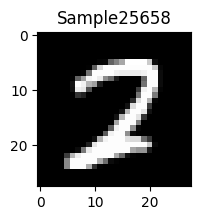

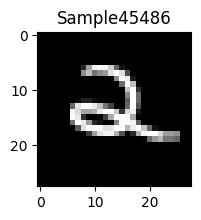

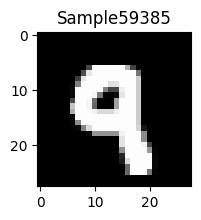

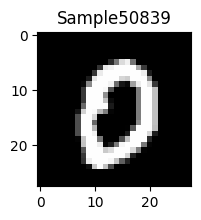

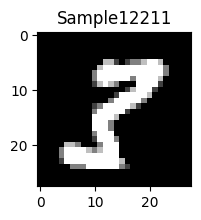

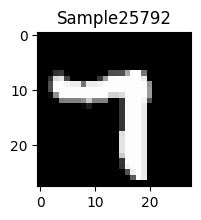

In [ ]:
def imshow(title, image = None, size = 6):

    if image.any():

        w, h = image.shape[0], image.shape[1]
        aspect_ratio = w/h
        plt.figure(figsize=(size * aspect_ratio,size))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.show()
    else:
        print("Image not found")


for i in range(0,6):

    random_num = np.random.randint(0, len(x_train))
    img = x_train[random_num]
    imshow(f"Sample{random_num}", img, size = 2)

<Figure size 640x480 with 0 Axes>

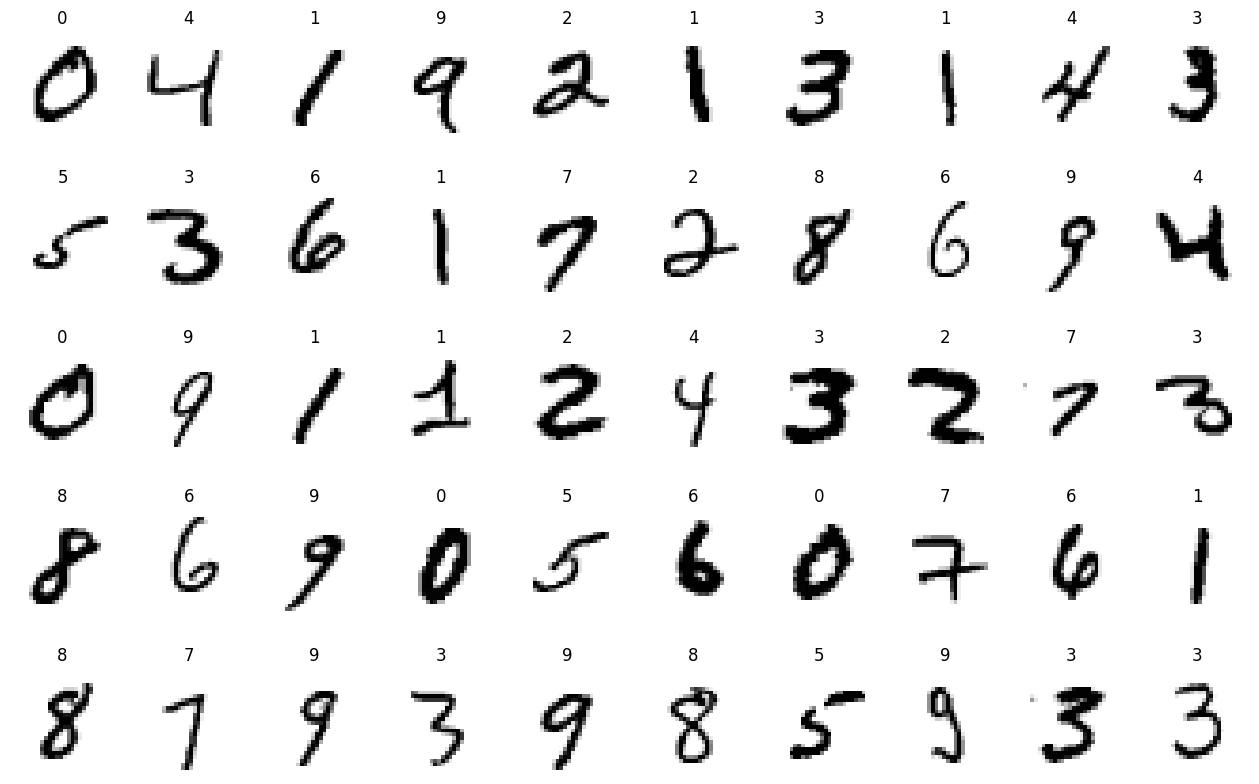

In [ ]:
figure = plt.figure()
plt.figure(figsize=(16,10))

num_of_images = 50

for index in range(1, num_of_images + 1):
    plt.subplot(5, 10, index).set_title(f'{y_train[index]}')
    plt.axis('off')
    plt.imshow(x_train[index], cmap='gray_r')

In [ ]:
img_rows = x_train[0].shape[0]
img_cols = x_train[0].shape[1]


# (60000,28,28) to (60000,28,28,1)
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)

input_shape = (img_rows, img_cols, 1)

# uint8 to float32
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

# Normalize our data
# x_train = x_train/255.0 # Convert Pixels from range [0,255] to [0,1]

x_train /= 255.0
x_test /= 255.0

print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [ ]:
print(img_rows, img_cols)

28 28


In [ ]:
from keras.utils import to_categorical

In [ ]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print ("Shape of Labels: " + str(y_test.shape))
print ("Number of Test Samples: " + str(y_test.shape[0]))
print ("Number of Classes: " + str(y_test.shape[1]))

num_classes = y_test.shape[1]
num_pixels = x_train.shape[1] * x_train.shape[2]

Shape of Labels: (10000, 10)
Number of Test Samples: 10000
Number of Classes: 10


In [ ]:
print(x_train.shape[1])
print(x_train.shape[2])

28
28


In [ ]:
num_classes

10

In [ ]:
num_pixels

784

In [ ]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [ ]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))

model.add(Conv2D(64, (3, 3), activation='relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(num_classes, activation='softmax'))

model.compile(loss = 'categorical_crossentropy', optimizer = SGD(learning_rate=0.001), metrics = ['accuracy','precision'])

print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
batch_size = 128
epoch = 25

In [ ]:
# model.fit()
# model.predict(x_test)

# history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epoch, validation_data=(x_test,y_test))

# 20% of the training data as model validation data
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epoch, validation_split=0.2)


Epoch 1/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.2768 - loss: 2.2715 - precision: 0.0000e+00 - val_accuracy: 0.4858 - val_loss: 2.2249 - val_precision: 0.0000e+00
Epoch 2/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5925 - loss: 2.1367 - precision: 0.0000e+00 - val_accuracy: 0.6921 - val_loss: 1.9867 - val_precision: 0.0000e+00
Epoch 3/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7265 - loss: 1.6399 - precision: 0.9984 - val_accuracy: 0.7972 - val_loss: 1.1498 - val_precision: 0.9956
Epoch 4/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8174 - loss: 0.8390 - precision: 0.9694 - val_accuracy: 0.8609 - val_loss: 0.5798 - val_precision: 0.9590
Epoch 5/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8627 - loss: 0.5302 - precision: 0.9414 - val_accuracy: 0.8853 - val_loss: 0.4307 - val_precision: 0.9441
Epoch 6/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8813 - loss: 0.4334 - precision: 0.9337 - val_accuracy: 0

In [ ]:
score = model.evaluate(x_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9430 - loss: 0.1981 - precision: 0.9570


In [ ]:
print('Test Loss: ' , score[0])
print('Test Accuracy : ' , score[1])

Test Loss:  0.19812099635601044
Test Accuracy :  0.9430000185966492


In [ ]:
history_dict = history.history
history_dict

{'accuracy': [0.27679166197776794,
  0.5925416946411133,
  0.726520836353302,
  0.817354142665863,
  0.8627499938011169,
  0.8813124895095825,
  0.8918125033378601,
  0.898104190826416,
  0.9029791951179504,
  0.9075416922569275,
  0.9103749990463257,
  0.9136458039283752,
  0.9165624976158142,
  0.9195208549499512,
  0.9213749766349792,
  0.9238541722297668,
  0.9255833625793457,
  0.9270208477973938,
  0.9293749928474426,
  0.9308541417121887,
  0.9324166774749756,
  0.9336041808128357,
  0.9352708458900452,
  0.9368333220481873,
  0.9382291436195374],
 'loss': [2.271536350250244,
  2.136678457260132,
  1.6399496793746948,
  0.8389858603477478,
  0.530228853225708,
  0.4334362745285034,
  0.3870600461959839,
  0.35847538709640503,
  0.338066965341568,
  0.32227015495300293,
  0.309411883354187,
  0.29797154664993286,
  0.2881220579147339,
  0.2791743278503418,
  0.27096208930015564,
  0.26328718662261963,
  0.2563747465610504,
  0.24946704506874084,
  0.2432829588651657,
  0.23741461

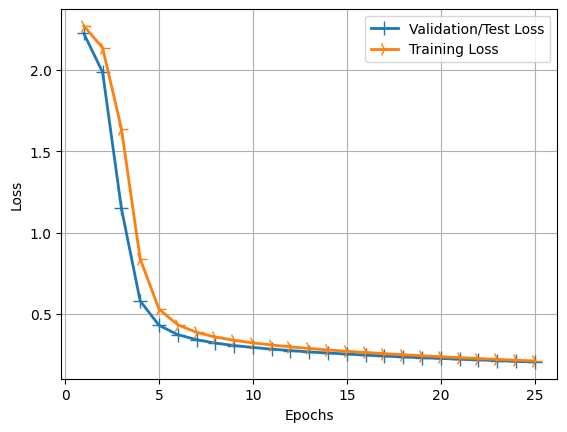

In [ ]:
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

epochs = range(1, len(loss_values) + 1)

line1 = plt.plot(epochs, val_loss_values, label='Validation/Test Loss')
line2 = plt.plot(epochs, loss_values, label='Training Loss')
plt.setp(line1, linewidth=2.0, marker = '+', markersize=10.0)
plt.setp(line2, linewidth=2.0, marker = '4', markersize=10.0)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

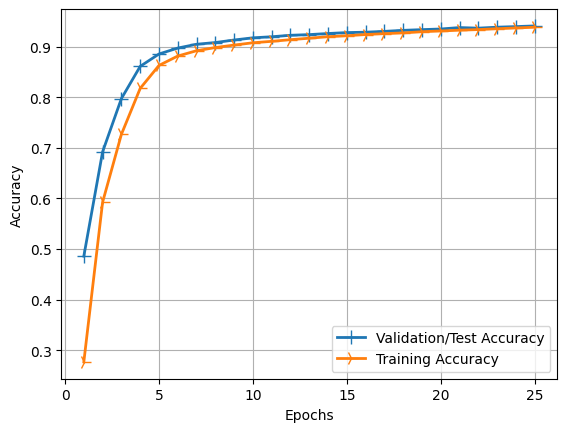

In [ ]:
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(loss_values) + 1)

line1 = plt.plot(epochs, val_acc_values, label='Validation/Test Accuracy')
line2 = plt.plot(epochs, acc_values, label='Training Accuracy')
plt.setp(line1, linewidth=2.0, marker = '+', markersize=10.0)
plt.setp(line2, linewidth=2.0, marker = '4', markersize=10.0)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
model.save("cnn_model_tensorflow.h5")

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
classifier = load_model('cnn_model_tensorflow.h5')

In [ ]:
print(x_test.shape)

print("Predicting classes for all 10,000 test images...")

pred = np.argmax(classifier.predict(x_test), axis=-1)
print("Completed.\n")

print(pred)
print(type(pred))
print(len(pred))

(10000, 28, 28, 1)
Predicting classes for all 10,000 test images...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Completed.

[7 2 1 ... 4 5 6]
<class 'numpy.ndarray'>
10000


In [ ]:
input_im = x_test[0]
print(input_im.shape)

input_im = input_im.reshape(1,28,28,1)
print(input_im.shape)

pred = np.argmax(classifier.predict(input_im), axis=-1)
print(pred)
print(type(pred))
print(len(pred))

(28, 28, 1)
(1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
[7]
<class 'numpy.ndarray'>
1


In [ ]:
def draw_test(name, pred, input_im):

    BLACK = [0,0,0]

    expanded_image = cv2.copyMakeBorder(input_im, 0, 0, 0, imageL.shape[0] ,cv2.BORDER_CONSTANT,value=BLACK)

    expanded_image = cv2.cvtColor(expanded_image, cv2.COLOR_GRAY2BGR)

    cv2.putText(expanded_image, str(pred), (150, 80) , cv2.FONT_HERSHEY_COMPLEX_SMALL, 4, (0,255,0), 2)

    imshow(name, expanded_image)

In [ ]:
(x_train, y_train), (x_test, y_test)  = mnist.load_data()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step


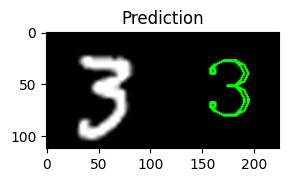

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


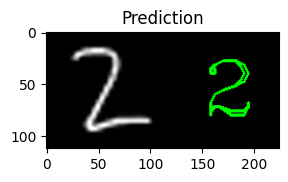

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


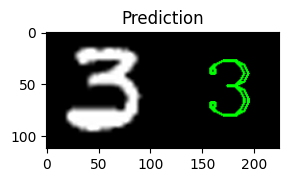

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


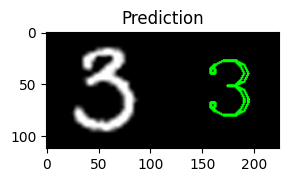

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


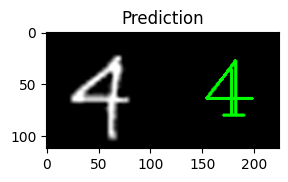

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


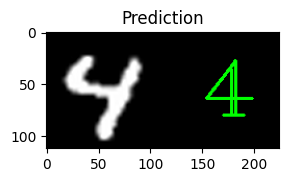

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


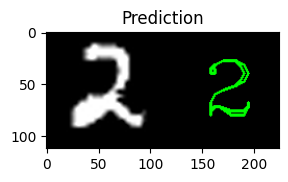

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


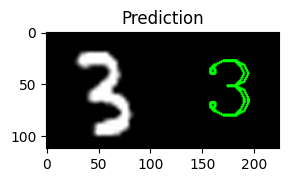

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


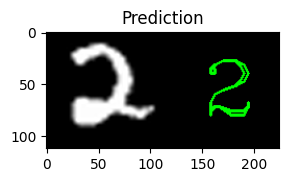

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


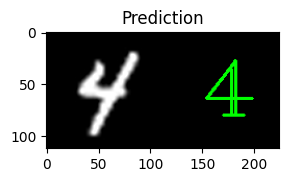

In [ ]:
for i in range(0,10):

    rand = np.random.randint(0,len(x_test))
    input_im = x_test[rand]

    imageL = cv2.resize(input_im, None, fx=4, fy=4, interpolation = cv2.INTER_CUBIC)

    input_im = input_im.reshape(1,28,28,1)

    res = str(np.argmax(classifier.predict(input_im), axis=-1)[0])

    draw_test("Prediction", res,  np.uint8(imageL))